In [66]:
import json
from pathlib import Path
import pandas as pd

from collections import defaultdict

from app.schemas import ModelEvaluation, GradingResult, KeyConcepts

In [67]:
from sentence_transformers import SentenceTransformer, util

In [68]:
embedder = SentenceTransformer("cointegrated/rubert-tiny2")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [69]:
dir_path = Path("../output/full_grading")

In [70]:
data: list[ModelEvaluation] = []

for model_dir in dir_path.iterdir():
    if model_dir.is_file():
        continue

    for evaluation_file in model_dir.iterdir():
        if evaluation_file.is_dir():
            continue

        content = evaluation_file.read_text(encoding="utf8")
        model_evaluation = ModelEvaluation.model_validate(json.loads(content))
        data.append(model_evaluation)

In [71]:
def calc_score(grading_result: GradingResult, key_concepts: KeyConcepts):
    global wrong
    global correct
    score = 0
    for i, concept_score in enumerate(grading_result.concepts):
        try:
            concept = key_concepts.concepts[concept_score.id - 1]
        except IndexError as e:
            raise ValueError("Wrong concept id")
        
        score += concept_score.coverage * concept.importance

    total_possible = sum(x.importance for x in key_concepts.concepts) * 2

    return score / total_possible * 100

In [72]:
def cosine_similarity(a, b):
    return float(util.cos_sim(a, b)[0][0])

In [73]:
scores = pd.DataFrame()

for item in data:
    try:
        grade_score = calc_score(item.grading_results, item.key_concepts)
    except ValueError as e:
        continue

    real_score = item.answer.quality
    
    embeddings = embedder.encode([item.question.reference_answer, item.answer.text])
    cos_sim = cosine_similarity(embeddings[0], embeddings[1])

    new_row = pd.DataFrame([{"model": item.model, "answer_type": item.answer.answer_type, "real_score": real_score, "model_score": grade_score, "cos_sim": cos_sim}])

    scores = pd.concat([scores, new_row], ignore_index=True)

In [74]:
scores["hybrid_score"] = scores["model_score"] * 0.35558306 + scores["cos_sim"] * 100 * 1.27842174 - 54

In [75]:
scores

,model,answer_type,real_score,model_score,cos_sim,hybrid_score
0,llama3-8b,Отличный,93,100.000000,0.835392,88.356597
1,llama3-8b,Очень слабый,9,57.446809,0.422791,20.477660
2,llama3-8b,Слабый,31,18.571429,0.639563,34.366759
3,llama3-8b,Средний,58,68.085106,0.742527,65.136231
4,llama3-8b,Средний,58,50.000000,0.619964,43.036760
...,...,...,...,...,...,...
1477,vikhr-8b,Средний,58,26.543210,0.684211,42.909324
1478,vikhr-8b,Слабый,31,16.666667,0.597779,28.347786
1479,vikhr-8b,Очень слабый,3,16.666667,0.502621,16.182576
1480,vikhr-8b,Отличный,97,60.000000,0.885440,80.531588


In [76]:
for linear in scores["model"].unique():

    print(linear)
    corr = scores[scores.model == linear]["real_score"].corr(scores[scores.model == linear]["model_score"], method="spearman")
    corr_emb = scores[scores.model == linear]["real_score"].corr(scores[scores.model == linear]["hybrid_score"], method="spearman")
    print(f"Корреляция оценок модели с реальными: {corr}")
    print(f"Корреляция гибридных оценок с реальными: {corr_emb}")

    print("Корреляция реальной оценки и гибридной для ответов типа:")
    for answer_type in scores["answer_type"].unique():
        df_slice = scores[(scores.model == linear) & (scores["answer_type"] == answer_type)]

        print(f"{answer_type}: {df_slice["real_score"].corr(scores["hybrid_score"], method="spearman")}")

llama3-8b
Корреляция оценок модели с реальными: 0.7611439933944707
Корреляция гибридных оценок с реальными: 0.9080232713285499
Корреляция реальной оценки и гибридной для ответов типа:
Отличный: 0.25266028353169195
Очень слабый: 0.42832020416167893
Слабый: 0.23407696157582938
Средний: -0.07262073666019545
Хороший: 0.217430260411507
tlite-8b
Корреляция оценок модели с реальными: 0.8221905734557207
Корреляция гибридных оценок с реальными: 0.9153138675355732
Корреляция реальной оценки и гибридной для ответов типа:
Отличный: 0.2426234574025055
Очень слабый: 0.4146812023231018
Слабый: 0.2037641034030187
Средний: 0.04017753629748746
Хороший: 0.22110037063185167
vikhr-8b
Корреляция оценок модели с реальными: 0.7377093685444558
Корреляция гибридных оценок с реальными: 0.8964405525346044
Корреляция реальной оценки и гибридной для ответов типа:
Отличный: 0.15674495063737018
Очень слабый: 0.4420173909802695
Слабый: 0.17917188064843498
Средний: -0.005273321240329186
Хороший: 0.18570286194613475


In [77]:
from sklearn.model_selection import train_test_split

In [86]:
tlite_scores = scores

In [87]:
tlite_scores["cos_sim"] *= 100

In [88]:
tlite_scores

,model,answer_type,real_score,model_score,cos_sim,hybrid_score
0,llama3-8b,Отличный,93,100.000000,83.539170,88.356597
1,llama3-8b,Очень слабый,9,57.446809,42.279121,20.477660
2,llama3-8b,Слабый,31,18.571429,63.956261,34.366759
3,llama3-8b,Средний,58,68.085106,74.252743,65.136231
4,llama3-8b,Средний,58,50.000000,61.996448,43.036760
...,...,...,...,...,...,...
1477,vikhr-8b,Средний,58,26.543210,68.421090,42.909324
1478,vikhr-8b,Слабый,31,16.666667,59.777927,28.347786
1479,vikhr-8b,Очень слабый,3,16.666667,50.262123,16.182576
1480,vikhr-8b,Отличный,97,60.000000,88.544023,80.531588


In [89]:
from sklearn.linear_model import LinearRegression

In [90]:
X_train, X_test, y_train, y_test = train_test_split(tlite_scores[["model_score", "cos_sim"]], tlite_scores["real_score"])

In [91]:
linear = LinearRegression().fit(X_train, y_train)

In [92]:
linear.coef_

array([0.34388266, 1.39581137])

In [93]:
linear.intercept_

np.float64(-63.00062436032553)

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [97]:
X = scores[['cos_sim', 'model_score']]
y = scores['answer_type']
clf = LogisticRegression(max_iter=10000)
acc = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.6316


In [99]:
clf.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

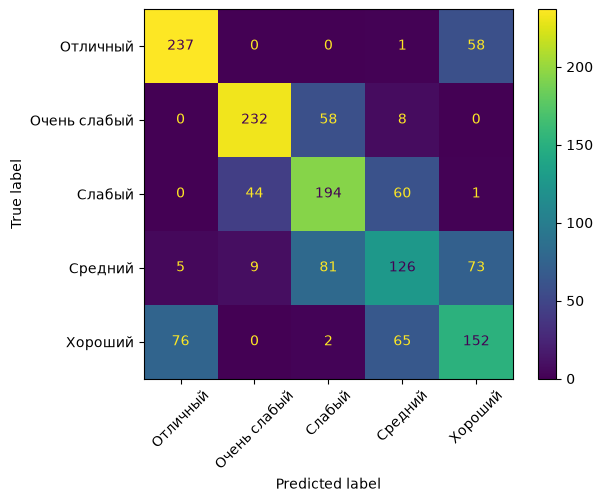

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

categories = y.unique()

cm = confusion_matrix(y, clf.predict(X), labels=categories)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(xticks_rotation=45)
plt.show()